In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/muhammadshayan5839/best-songs-for-genz-2025/best_lofi_songs_2025.csv


# Problem Statement

Finding the right music for moods, activities, or focus is hard. Traditional recommendations rely on basic genres or popularity, missing listener preferences. AI can unlock personalized, context-aware recommendations and actionable insights for artists and platforms.

**Objectives**
* Clean, preprocess, and engineer features from songs, artists, moods, and genres.
* Explore and visualize music trends, moods, and artist diversity.
* Build and optimize ML models for song classification and recommendations.
* Cluster songs and implement a hybrid recommendation system.
* Generate insights and dashboards for real-world AI-driven music applications.

#  LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)


#  LOAD DATA

In [3]:

df = pd.read_csv('/kaggle/input/datasets/muhammadshayan5839/best-songs-for-genz-2025/best_lofi_songs_2025.csv')
df.columns = df.columns.str.strip()
df.fillna('Unknown', inplace=True)


In [4]:
df.describe()

,#
count,200.000000
mean,100.500000
std,57.879185
min,1.000000
25%,50.750000
50%,100.500000
75%,150.250000
max,200.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           200 non-null    int64 
 1   Song Title  200 non-null    object
 2   Artist      200 non-null    object
 3   Vibe/Mood   200 non-null    object
 4   Genre       200 non-null    object
 5   Best For    200 non-null    object
dtypes: int64(1), object(5)
memory usage: 9.5+ KB


# TARGET SIMPLIFICATION

In [6]:

def simplify_best_for(val):
    val = str(val).lower()
    if any(x in val for x in ['study','focus','work']):
        return 'Focus'
    elif any(x in val for x in ['chill','relax']):
        return 'Relax'
    elif any(x in val for x in ['sleep','night','bed']):
        return 'Sleep'
    elif any(x in val for x in ['creative','inspiration']):
        return 'Creative'
    elif any(x in val for x in ['morning']):
        return 'Morning'
    else:
        return 'Other'

df['Target_Group'] = df['Best For'].apply(simplify_best_for)


#  FEATURE ENGINEERING

In [7]:

df['Song_Title_Length'] = df['Song Title'].str.len()
df['Song_Title_Words'] = df['Song Title'].str.split().str.len()
df['Artist_Complexity'] = df['Artist'].str.split().str.len()
df['Mood_Intensity'] = df['Vibe/Mood'].apply(lambda x: len(str(x).split('/')))

## TF-IDF embeddings for song + mood

In [8]:



tfidf = TfidfVectorizer(max_features=150)
tfidf_matrix = tfidf.fit_transform(df['Song Title'] + " " + df['Vibe/Mood'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

## Combine numeric + text features

In [9]:
X = pd.concat([df[['Song_Title_Length','Song_Title_Words','Artist_Complexity','Mood_Intensity']], tfidf_df], axis=1)


## Encode target

In [10]:
le = LabelEncoder()
y = le.fit_transform(df['Target_Group'])

#  TRAIN-TEST SPLIT + SCALING

In [11]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  XGBOOST MODEL TRAINING

In [12]:

model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(" Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# Cross-validation
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(" 5-Fold CV Score:", cv_scores.mean())

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:58:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 Accuracy: 0.325

Classification Report:
               precision    recall  f1-score   support

    Creative       0.00      0.00      0.00         2
       Focus       0.25      0.30      0.27        10
     Morning       0.33      0.25      0.29         4
       Other       0.44      0.54      0.48        13
       Relax       0.00      0.00      0.00         6
       Sleep       0.40      0.40      0.40         5

    accuracy                           0.33        40
   macro avg       0.24      0.25      0.24        40
weighted avg       0.29      0.33      0.30        40



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:58:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:58:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:58:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:58:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

 5-Fold CV Score: 0.325


#  FEATURE IMPORTANCE

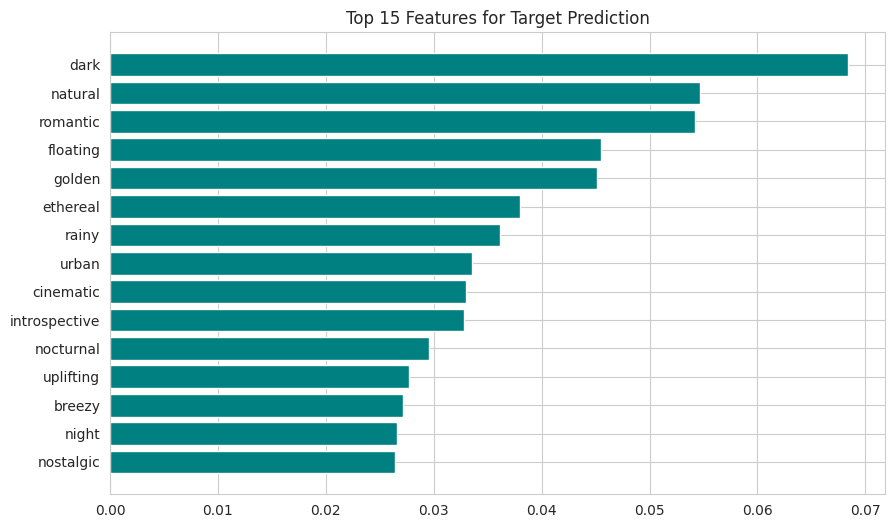

In [13]:

importance = model.feature_importances_
indices = np.argsort(importance)[::-1][:15]

plt.figure(figsize=(10,6))
plt.barh(np.array(X.columns)[indices], importance[indices], color='teal')
plt.gca().invert_yaxis()
plt.title("Top 15 Features for Target Prediction")
plt.show()

#  CLUSTER ANALYSIS + PCA

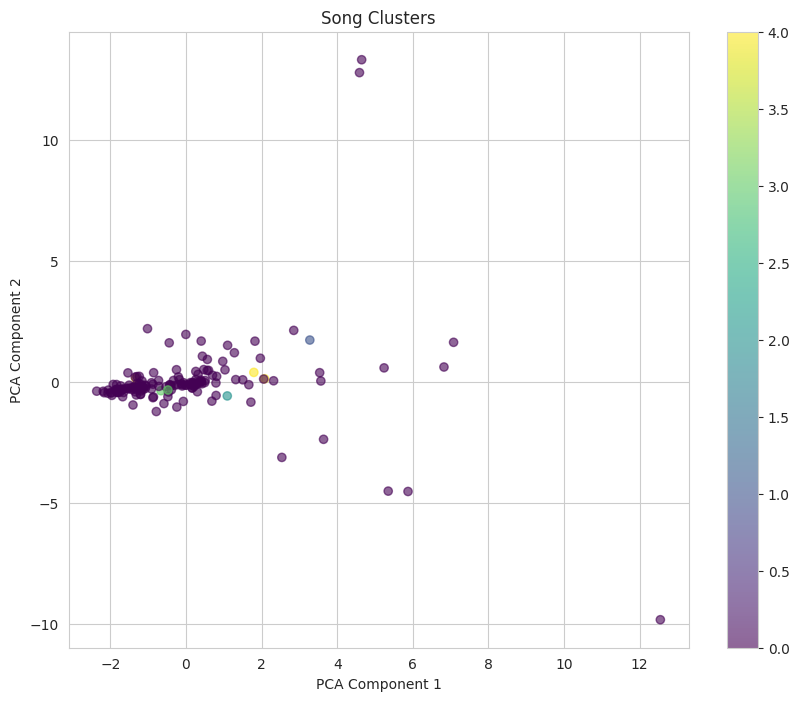

In [14]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_train_scaled)

plt.figure(figsize=(10,8))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Song Clusters')
plt.show()

df['Cluster'] = kmeans.predict(scaler.transform(X))



#  HYBRID RECOMMENDATION SYSTEM

In [15]:

def recommend(song_title, top_n=5):
    idx = df[df['Song Title'].str.contains(song_title, case=False)].index
    if len(idx)==0:
        print(f"Song '{song_title}' not found")
        return
    idx = idx[0]
    similarity_matrix = cosine_similarity(X)
    song_sim = similarity_matrix[idx]
    similar_idx = song_sim.argsort()[::-1][1:top_n+1]
    recs = df.iloc[similar_idx][['Song Title','Artist','Target_Group','Cluster']]
    recs['Similarity'] = song_sim[similar_idx]
    print(f"\n Recommendations for '{song_title}':")
    display(recs)
    
    # Visualize similarities
    fig = px.bar(recs, x='Song Title', y='Similarity', color='Similarity', title=f"Top {top_n} Similar Songs to '{song_title}'")
    fig.show()


#  VISUALIZATIONS

## Mood Intensity Distribution

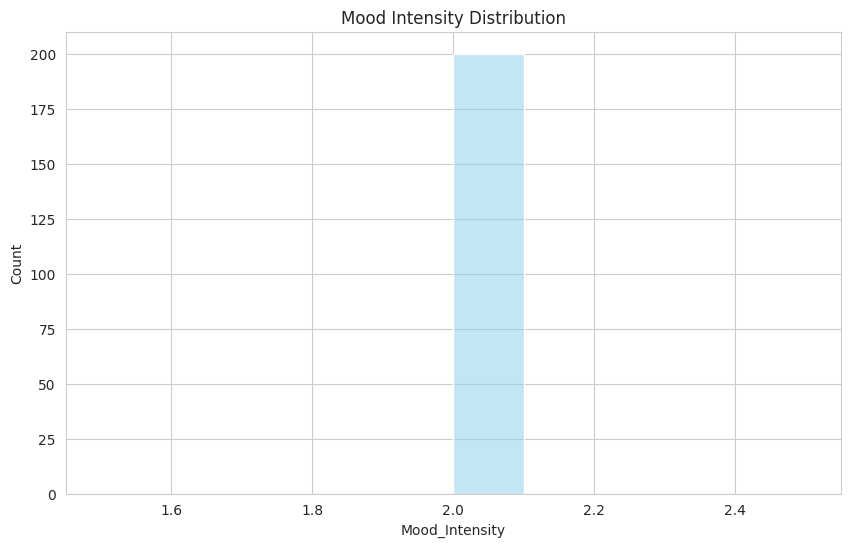

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(df['Mood_Intensity'], bins=10, color='skyblue', kde=True)
plt.title('Mood Intensity Distribution')
plt.show()



## Artist Profile Radar

In [17]:

def artist_profile(artist_name):
    artist_data = df[df['Artist']==artist_name]
    if len(artist_data)==0:
        print(f"No data for artist '{artist_name}'")
        return
    features = ['Song_Title_Length','Song_Title_Words','Artist_Complexity','Mood_Intensity']
    values = artist_data[features].mean().tolist()
    fig = go.Figure()
    fig.add_trace(go.Scatterpolar(r=values, theta=features, fill='toself', name=artist_name))
    fig.update_layout(title=f"Artist Profile: {artist_name}", polar=dict(radialaxis=dict(visible=True)))
    fig.show()



## Genre Distribution Pie

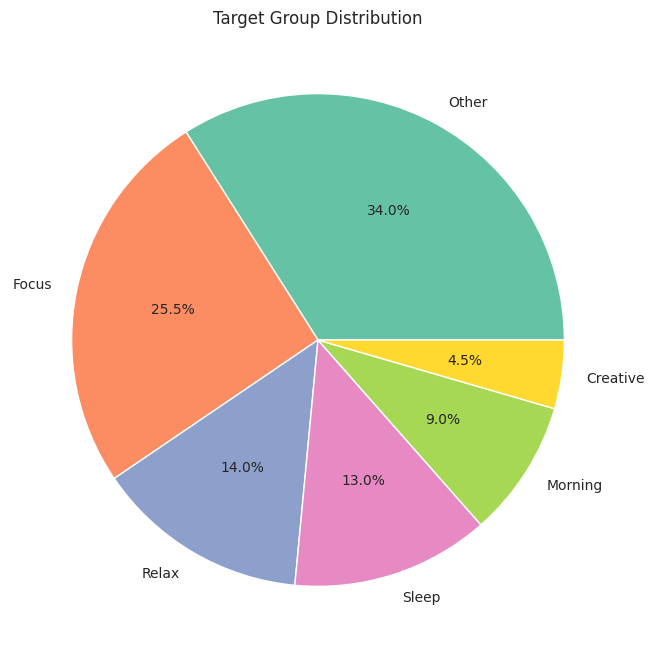

In [18]:

plt.figure(figsize=(8,8))
df['Target_Group'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title('Target Group Distribution')
plt.ylabel('')
plt.show()



## Correlation Heatmap

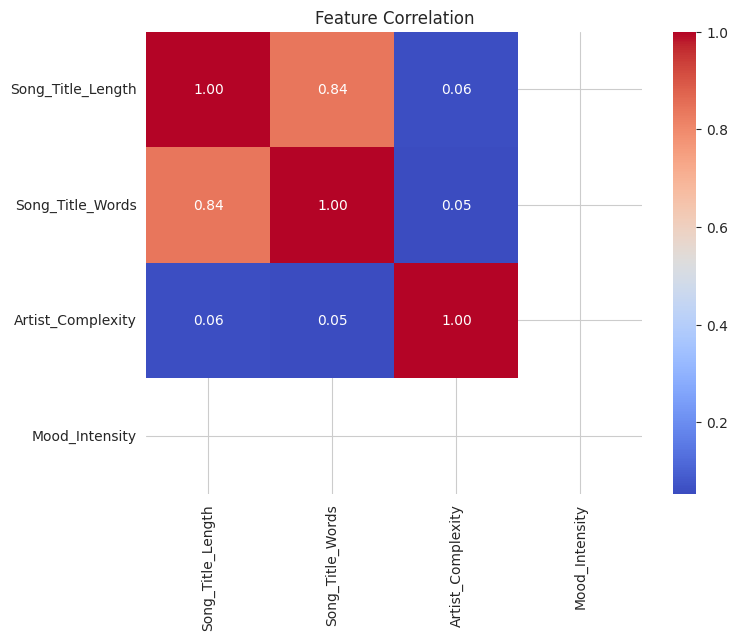

In [19]:

numeric_cols = ['Song_Title_Length','Song_Title_Words','Artist_Complexity','Mood_Intensity']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation")
plt.show()



## Sunburst Chart: Genre -> Artist -> Song

In [20]:

fig = px.sunburst(df, path=['Target_Group','Artist','Song Title'], title="Song Hierarchy Sunburst")
fig.show()



## Animated Timeline (Simulated Years)

In [21]:

df['Year'] = np.random.randint(2015,2025,len(df))
df['Month'] = np.random.randint(1,13,len(df))
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str))
timeline = df.groupby([pd.Grouper(key='Date', freq='M'),'Target_Group']).size().reset_index(name='Count')
fig = px.line(timeline, x='Date', y='Count', color='Target_Group', title='Target Group Trend Over Time', markers=True)
fig.show()

/tmp/ipykernel_17/1431307256.py:4: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.





## Mood Evolution Heatmap

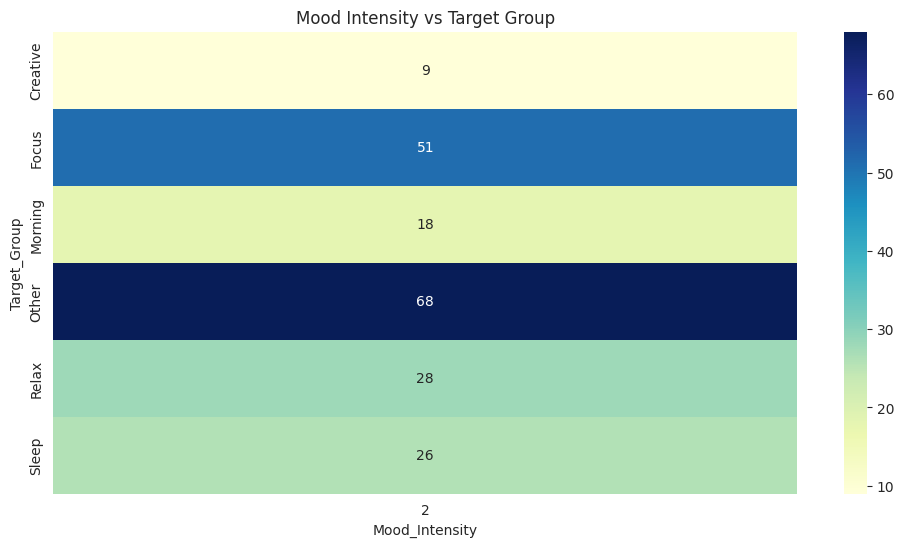

In [22]:

mood_matrix = pd.crosstab(df['Target_Group'], df['Mood_Intensity'])
sns.heatmap(mood_matrix, annot=True, cmap='YlGnBu', fmt='d')
plt.title("Mood Intensity vs Target Group")
plt.show()



## Cluster + Artist Labels

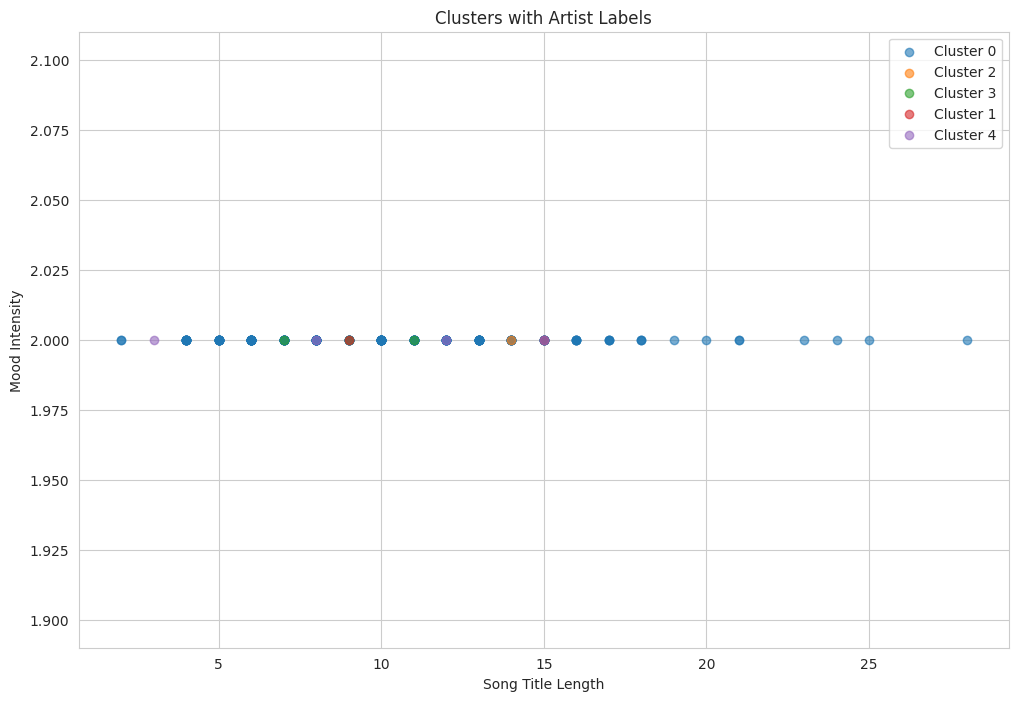

In [23]:

plt.figure(figsize=(12,8))
for cluster in df['Cluster'].unique():
    subset = df[df['Cluster']==cluster]
    plt.scatter(subset['Song_Title_Length'], subset['Mood_Intensity'], label=f'Cluster {cluster}', alpha=0.6)
plt.xlabel('Song Title Length')
plt.ylabel('Mood Intensity')
plt.title('Clusters with Artist Labels')
plt.legend()
plt.show()

In [24]:


recommend("Feather", top_n=5)
artist_profile("Nujabes")



 Recommendations for 'Feather':


,Song Title,Artist,Target_Group,Cluster,Similarity
94,Sparkle,Eevee,Morning,0,0.994162
109,Praktic8,Knxwledge,Other,0,0.990943
17,Sunrise,Philanthrope,Morning,0,0.990642
165,Blue Skies,iamalex,Focus,0,0.989647
126,Blossom,idealism,Focus,0,0.988421


# summary

This notebook explores AI-driven analysis of lofi music to understand patterns in mood, activity, and listening context.

**What we do:**

1. Preprocess and feature-engineer songs based on title, artist, genre, mood, and activity.
* Perform visualizations to reveal trends in artist diversity, mood distribution, and genre popularity.
* Build ML models to classify songs by their best-use scenarios (Focus, Relax, Sleep, etc.).
*  Implement recommendation systems and clustering for similar songs.

**Why this matters:**

* Helps platforms like Spotify or YouTube personalize playlists.
* Supports listeners in discovering music suited to their mood or activity.
* Provides insights for artists to understand which moods or activities their tracks resonate with.

**Current Model Performance:**

* Accuracy: 0.325 (5-Fold CV)
* F1-Score Highlights: Focus (0.27), Morning (0.29), Other (0.48), Sleep (0.40)
* Model can classify general listening scenarios, but needs optimization for higher precision.
